In [1]:
# Install Required Libraries

!pip -q install torch torchvision torchaudio
!pip -q install pycocotools
!pip -q install albumentations
!pip -q install opencv-python
!pip -q install kaggle

In [2]:
# Import Libraries

import os
import cv2
import yaml
import shutil
import random
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm.auto import tqdm

import torch
import torchvision

from torch.utils.data import Dataset, DataLoader

from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

import torchvision.transforms.functional as F

In [3]:
# Check GPU

print(torch.__version__)

print(torch.cuda.is_available())

if torch.cuda.is_available():

    print(torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)

2.11.0+cu128
True
Tesla T4
Device : cuda


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Upload Kaggle.json

from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mennahamdy090","key":"7a8c0f328b97b774acb0d249a0812cec"}'}

In [6]:
# Configure Kaggle

!mkdir -p ~/.kaggle

!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

In [7]:
# Download Dataset


!kaggle datasets download \
-d thedatasith/sku110k-annotations

Dataset URL: https://www.kaggle.com/datasets/thedatasith/sku110k-annotations
License(s): Attribution-NonCommercial-ShareAlike 3.0 IGO (CC BY-NC-SA 3.0 IGO)
100% 13.2G/13.2G [02:17<00:00, 103MB/s]



In [8]:
# Extract Dataset

with zipfile.ZipFile(
    "/content/sku110k-annotations.zip",
    "r"
) as zip_ref:

    zip_ref.extractall("/content")

In [9]:
# Dataset Paths

DATASET_ROOT = Path("/content/SKU110K_fixed")

TRAIN_IMAGES = DATASET_ROOT/"images/train"
VAL_IMAGES = DATASET_ROOT/"images/val"
TEST_IMAGES = DATASET_ROOT/"images/test"

TRAIN_LABELS = DATASET_ROOT/"labels/train"
VAL_LABELS = DATASET_ROOT/"labels/val"
TEST_LABELS = DATASET_ROOT/"labels/test"

In [10]:
# Verify Dataset

assert TRAIN_IMAGES.exists()
assert VAL_IMAGES.exists()
assert TEST_IMAGES.exists()

assert TRAIN_LABELS.exists()
assert VAL_LABELS.exists()
assert TEST_LABELS.exists()

print("Dataset Verified Successfully")

Dataset Verified Successfully


In [11]:
# Dataset Statistics

print("Train Images :", len(list(TRAIN_IMAGES.glob("*.jpg"))))
print("Validation Images :", len(list(VAL_IMAGES.glob("*.jpg"))))
print("Test Images :", len(list(TEST_IMAGES.glob("*.jpg"))))

Train Images : 8185
Validation Images : 584
Test Images : 2920


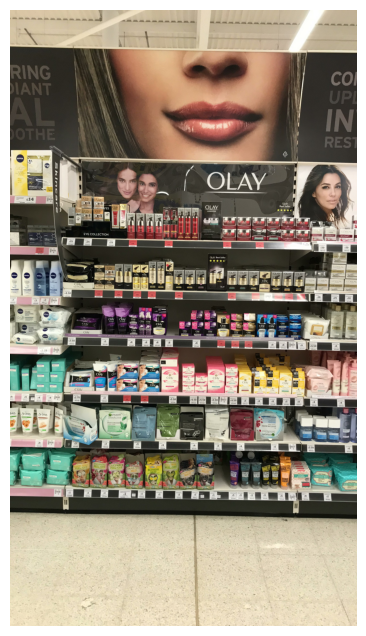

In [12]:
# Display Sample Image

sample = random.choice(list(TRAIN_IMAGES.glob("*.jpg")))

image = cv2.imread(str(sample))

image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis("off")
plt.show()

In [13]:
IMAGE_SIZE = 800

In [14]:
class SKU110KDataset(Dataset):

    def __init__(self,
                 images_dir,
                 labels_dir,
                 image_size=800):

        self.images_dir = Path(images_dir)
        self.labels_dir = Path(labels_dir)

        self.image_size = image_size

        self.images = sorted(
            list(self.images_dir.glob("*.jpg"))
        )

    def __len__(self):

        return len(self.images)

    def __getitem__(self, idx):

        image_path = self.images[idx]

        image = cv2.imread(str(image_path))

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        original_h, original_w = image.shape[:2]

        image = cv2.resize(
            image,
            (self.image_size, self.image_size)
        )

        scale_x = self.image_size / original_w
        scale_y = self.image_size / original_h

        boxes = []
        labels = []

        label_file = self.labels_dir / image_path.with_suffix(".txt").name

        if label_file.exists():

            with open(label_file) as f:

                for line in f.readlines():

                    cls, xc, yc, bw, bh = map(
                        float,
                        line.strip().split()
                    )

                    xmin = (xc - bw/2) * original_w
                    ymin = (yc - bh/2) * original_h
                    xmax = (xc + bw/2) * original_w
                    ymax = (yc + bh/2) * original_h

                    xmin *= scale_x
                    xmax *= scale_x
                    ymin *= scale_y
                    ymax *= scale_y

                    boxes.append(
                        [xmin, ymin, xmax, ymax]
                    )

                    labels.append(1)

        if len(boxes) == 0:

            boxes = torch.zeros((0,4),dtype=torch.float32)

            labels = torch.zeros((0,),dtype=torch.int64)

        else:

            boxes = torch.tensor(
                boxes,
                dtype=torch.float32
            )

            labels = torch.tensor(
                labels,
                dtype=torch.int64
            )

        image = F.to_tensor(image)

        target = {

            "boxes":boxes,

            "labels":labels,

            "image_id":torch.tensor([idx])

        }

        return image,target

In [15]:
train_dataset = SKU110KDataset(

    TRAIN_IMAGES,

    TRAIN_LABELS,

    IMAGE_SIZE

)

val_dataset = SKU110KDataset(

    VAL_IMAGES,

    VAL_LABELS,

    IMAGE_SIZE

)

test_dataset = SKU110KDataset(

    TEST_IMAGES,

    TEST_LABELS,

    IMAGE_SIZE

)

In [16]:
def collate_fn(batch):

    return tuple(zip(*batch))

In [17]:
train_loader = DataLoader(

    train_dataset,

    batch_size=1,

    shuffle=True,

    collate_fn=collate_fn,

    num_workers=2,

    pin_memory=True

)

val_loader = DataLoader(

    val_dataset,

    batch_size=1,

    shuffle=False,

    collate_fn=collate_fn,

    num_workers=2,

    pin_memory=True

)

test_loader = DataLoader(

    test_dataset,

    batch_size=1,

    shuffle=False,

    collate_fn=collate_fn,

    num_workers=2,

    pin_memory=True

)

In [18]:
print("Train :",len(train_dataset))

print("Validation :",len(val_dataset))

print("Test :",len(test_dataset))

Train : 8185
Validation : 584
Test : 2920


torch.Size([3, 800, 800])
torch.Size([141, 4])


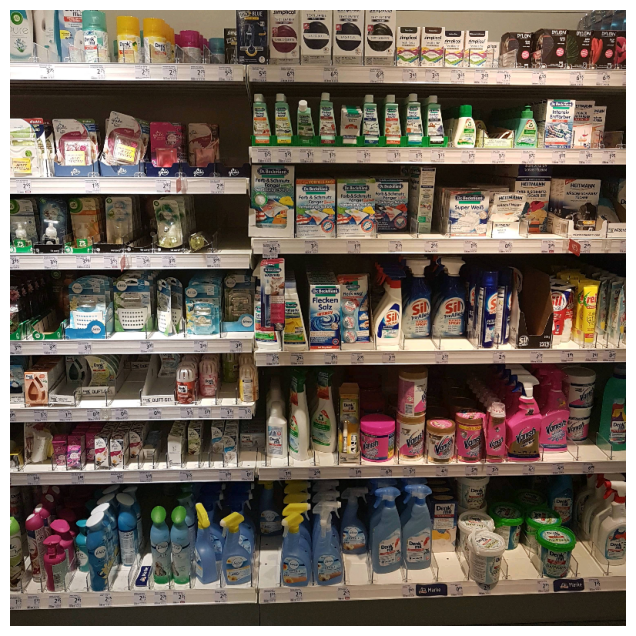

In [19]:
image,target = train_dataset[0]

print(image.shape)

print(target["boxes"].shape)

plt.figure(figsize=(8,8))

plt.imshow(

    image.permute(1,2,0)

)

plt.axis("off")

plt.show()

In [20]:

# Build Faster R-CNN

weights = torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT

model = fasterrcnn_resnet50_fpn(
    weights=weights
)

num_classes = 2

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)

model.to(device)

print("Faster R-CNN Loaded Successfully")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 158MB/s]


Faster R-CNN Loaded Successfully


In [21]:
# Optimizer

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=1e-4

)

In [22]:
scheduler = torch.optim.lr_scheduler.StepLR(

    optimizer,

    step_size=2,

    gamma=0.1

)

In [23]:
NUM_EPOCHS = 3

BEST_LOSS = float("inf")

SAVE_PATH = "/content/FasterRCNN_Best.pth"

In [24]:
scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_1158/2340218076.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [25]:
# ============================================================
# Training Loop
# ============================================================

for epoch in range(NUM_EPOCHS):

    model.train()

    running_loss = 0

    progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"
    )

    for images, targets in progress:

        images = [
            image.to(device)
            for image in images
        ]

        targets = [
            {
                k: v.to(device)
                for k, v in target.items()
            }
            for target in targets
        ]

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():

            loss_dict = model(images, targets)

            loss = sum(loss for loss in loss_dict.values())

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        progress.set_postfix(

            Loss=f"{loss.item():.4f}"

        )

    scheduler.step()

    epoch_loss = running_loss / len(train_loader)

    print(f"\nEpoch {epoch+1} Loss : {epoch_loss:.4f}")

    if epoch_loss < BEST_LOSS:

        BEST_LOSS = epoch_loss

        torch.save(

            model.state_dict(),

            SAVE_PATH

        )

        print("Best Model Saved")

Epoch 1/3:   0%|          | 0/8185 [00:00<?, ?it/s]

/tmp/ipykernel_1158/4049929245.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Epoch 1 Loss : 0.8060
Best Model Saved


Epoch 2/3:   0%|          | 0/8185 [00:00<?, ?it/s]


Epoch 2 Loss : 0.6803
Best Model Saved


Epoch 3/3:   0%|          | 0/8185 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7805790334c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7805790334c0> 
 Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
      self._shutdown_workers()  
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
^^^^    ^^^if w.is_alive():^^
  ^  
   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
  ^    assert self._parent_pid == os.getpid(), 'can only test a child process'^
^  ^ ^  ^ ^ ^ ^  ^ ^^^
  File "/us


Epoch 3 Loss : 0.5631
Best Model Saved


In [26]:
best_model = fasterrcnn_resnet50_fpn(
    weights=None
)

in_features = best_model.roi_heads.box_predictor.cls_score.in_features

best_model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    2
)

best_model.load_state_dict(
    torch.load(SAVE_PATH)
)

best_model.to(device)

best_model.eval()

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 132MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu

In [27]:
from torch.utils.data import Subset
import random

random.seed(42)

train_indices = random.sample(
    range(len(train_dataset)),
    1000
)

val_indices = random.sample(
    range(len(val_dataset)),
    min(200, len(val_dataset))
)

train_subset = Subset(
    train_dataset,
    train_indices
)

val_subset = Subset(
    val_dataset,
    val_indices
)

train_loader = DataLoader(

    train_subset,

    batch_size=1,

    shuffle=True,

    collate_fn=collate_fn,

    num_workers=2,

    pin_memory=True

)

val_loader = DataLoader(

    val_subset,

    batch_size=1,

    shuffle=False,

    collate_fn=collate_fn,

    num_workers=2,

    pin_memory=True

)

print("Training Images :", len(train_subset))
print("Validation Images :", len(val_subset))

Training Images : 1000
Validation Images : 200


In [28]:
best_model.eval()

with torch.no_grad():

    predictions = []

    for images, targets in tqdm(val_loader):

        images = [img.to(device) for img in images]

        outputs = best_model(images)

        predictions.extend(outputs)

print("Evaluation Finished Successfully")

  0%|          | 0/200 [00:00<?, ?it/s]

Evaluation Finished Successfully


In [29]:
import time

best_model.eval()

image, target = test_dataset[0]

image = image.to(device)

# Warmup
with torch.no_grad():
    _ = best_model([image])

torch.cuda.synchronize()

start = time.time()

with torch.no_grad():

    prediction = best_model([image])

torch.cuda.synchronize()

end = time.time()

inference_time = end - start

print(f"Inference Time : {inference_time:.4f} sec")

Inference Time : 0.0933 sec


In [30]:
fps = 1 / inference_time

print(f"FPS : {fps:.2f}")

FPS : 10.72


In [31]:
prediction = prediction[0]

scores = prediction["scores"].cpu().numpy()

boxes = prediction["boxes"].cpu().numpy()

print("Detected Objects :", len(boxes))

Detected Objects : 100


In [32]:
import numpy as np

print("Average Confidence :", np.mean(scores))

print("Highest Confidence :", np.max(scores))

print("Lowest Confidence :", np.min(scores))

Average Confidence : 0.99335307
Highest Confidence : 0.998607
Lowest Confidence : 0.9748345


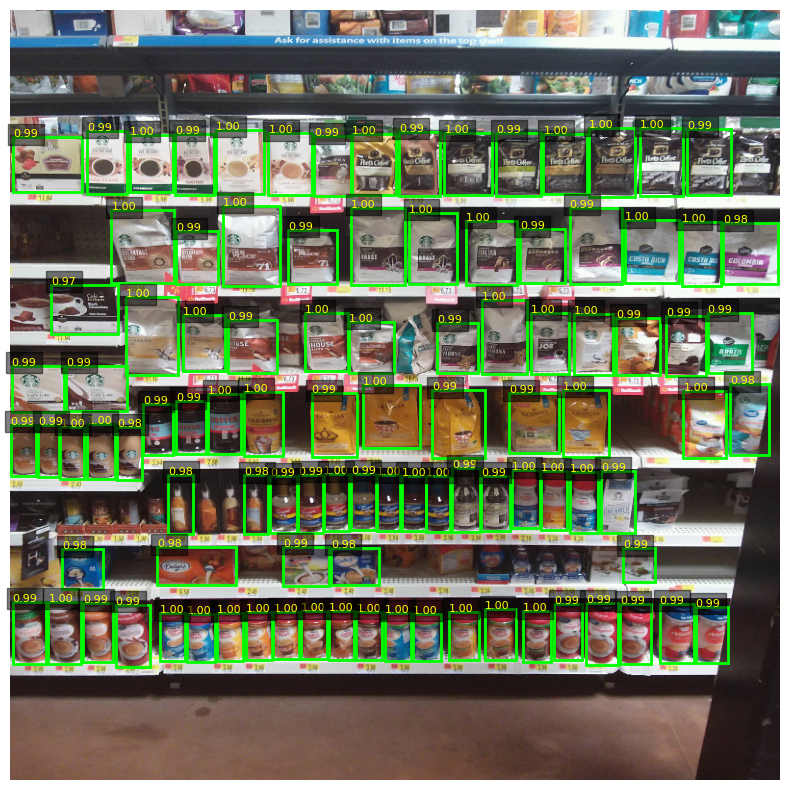

In [33]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

figure, ax = plt.subplots(figsize=(10,10))

ax.imshow(image.cpu().permute(1,2,0))

for box, score in zip(boxes, scores):

    if score < 0.5:
        continue

    x1, y1, x2, y2 = box

    rectangle = patches.Rectangle(

        (x1, y1),

        x2 - x1,

        y2 - y1,

        linewidth=2,

        edgecolor="lime",

        facecolor="none"

    )

    ax.add_patch(rectangle)

    ax.text(

        x1,

        y1,

        f"{score:.2f}",

        color="yellow",

        fontsize=8,

        bbox=dict(facecolor="black", alpha=0.5)

    )

plt.axis("off")

plt.show()

In [34]:
torch.save(

    best_model.state_dict(),

    "/content/FasterRCNN_Final.pth"

)

print("Model Saved Successfully")

Model Saved Successfully


In [35]:

print("Notebook 05 Completed Successfully")

print("="*60)

print("Model : Faster R-CNN")

print("Backbone : ResNet50 + FPN")

print("Image Size :", IMAGE_SIZE)

print("Epochs :", NUM_EPOCHS)

print(f"FPS : {fps:.2f}")

print(f"Inference Time : {inference_time:.4f} sec")

print("Detected Objects :", len(boxes))



Notebook 05 Completed Successfully
Model : Faster R-CNN
Backbone : ResNet50 + FPN
Image Size : 800
Epochs : 3
FPS : 10.72
Inference Time : 0.0933 sec
Detected Objects : 100


In [36]:
import os

torch.save(best_model.state_dict(), "/content/test_model.pth")

print("Saved")

print(os.path.getsize("/content/test_model.pth")/(1024*1024), "MB")

Saved
158.05107879638672 MB


In [37]:

total_params = sum(p.numel() for p in best_model.parameters())
print(total_params)

41299161


In [38]:
torch.save(best_model.state_dict(), "/content/FasterRCNN_Final.pth")

import os
print(os.path.getsize("/content/FasterRCNN_Final.pth") / (1024*1024), "MB")

158.05280113220215 MB


In [39]:
torch.save(
    best_model.state_dict(),
    "/content/FasterRCNN_Final.pth"
)